## Módulo 2 - Aprendizagem Automática para Mobilidade e Qualidade do Ar

### 1. Introdução

**Contexto**

A câmara municipal pretende prever a qualidade do ar para ajustar planos de tráfego e alertas à população.

**Tarefas**
1. Fazer EDA (estatísticas, histogramas, correlações, missing values)
2. Criar pré-processamento (normalização, imputação, split treino/teste)
3. Treinar ≥ 2 algoritmos de classificação (ex.: Logistic Regression, Random Forest) para prever `air_quality_good`
4. Treinar pelo menos um algoritmo de regressão para prever `NO2`
5. Comparar métricas e justificar a escolha do modelo final
6. Guardar modelos e métricas em ficheiros (`.pkl`, `.csv`)

### 2. Dados

Trabalhamos sobre o `data/clean_air_quality.csv` (versão tratada produzida no Módulo 1), em vez do ficheiro raw original. Vantagens:

- Dados já filtrados a Lisboa+Porto (1442 linhas)
- Colunas vazias já removidas
- Permite comparação directa com a Rede Bayesiana do Módulo 1 no final

**Ponto de atenção:** a coluna `air_quality_good` foi **recalculada no Módulo 1** com a seguinte fórmula:

`air_quality_good = False  quando  (NO2 >= 30 µg/m³) AND (humidade >= 80%)`

Razão: a coluna original era sempre `True` em Lisboa+Porto, sem variação para treinar modelos. A nova fórmula introduz variabilidade (~10% de casos "má"). Como NO2 e humidade definem a target, vão ter que ser excluídas das features na classificação (caso contrário data leakage).

### 3. Configuração do Ambiente e Importação de Dados

#### 3.1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Configurações de display
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 100

In [2]:
# ----------------------------------------------------------
# Paths — alterar aqui se mudarmos a localização dos ficheiros
# ----------------------------------------------------------
ROOT        = Path("..").resolve()
DATA_CSV    = ROOT / "data" / "clean_air_quality.csv"         # input (vem do Módulo 1)
METRICS_CSV = ROOT / "Module_2" / "resultados" / "metrics.csv"
MODEL_DIR   = ROOT / "Module_2" / "resultados"

# Outputs gerados (CSV) para os respectivos train_*.py
CLASSIFICATION_DF       = ROOT / "data" / "classification_data_clean.csv"
CLASSIFICATION_DF_NO_CO = ROOT / "data" / "classification_data_clean_no_co.csv"
REGRESSION_DF           = ROOT / "data" / "regression_data_clean.csv"

#### 3.2. Carregamento do Dataset

In [3]:
# Carregar o dataset limpo (gerado pelo Módulo 1)
df = pd.read_csv(DATA_CSV, sep=';')

print(f"Dataset: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"Cidades : {df['city'].unique().tolist()}")
print(f"Período : meses {sorted(df['month'].unique().tolist())}")
print(f"\nPrimeiras linhas:")
df.head()

Dataset: 1442 linhas × 17 colunas
Cidades : ['Lisboa', 'Porto']
Período : meses [9, 10]

Primeiras linhas:


,city,datetime,CO,NO2,O3,PM10,PM2.5,SO2,temperature_c,humidity_percent,pressure_hpa,wind_speed_kmh,wind_direction_deg,precipitation_mm,air_quality_good,year,month
0,Lisboa,05/09/25 01:00,0.96,25.20,84.09,11.82,9.12,6.75,18.9,82.0,1018.5,16.2,357.0,0.0,True,2025,9
1,Lisboa,05/09/25 02:00,0.75,26.40,86.20,13.24,8.87,5.11,18.8,80.0,1018.3,15.5,356.0,0.0,True,2025,9
2,Lisboa,05/09/25 03:00,0.87,25.16,74.41,15.18,10.84,5.76,18.6,79.0,1017.4,11.5,2.0,0.0,True,2025,9
3,Lisboa,05/09/25 04:00,0.51,13.59,68.57,17.48,13.14,5.03,18.3,77.0,1017.2,11.3,351.0,0.0,True,2025,9
4,Lisboa,05/09/25 05:00,0.61,15.89,78.79,14.70,13.68,6.20,18.6,72.0,1016.8,9.4,356.0,0.0,True,2025,9


In [4]:
# Estrutura geral (tipos das colunas, nulos, memória)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1442 entries, 0 to 1441
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   city                1442 non-null   object 
 1   datetime            1442 non-null   object 
 2   CO                  1442 non-null   float64
 3   NO2                 1442 non-null   float64
 4   O3                  1442 non-null   float64
 5   PM10                1442 non-null   float64
 6   PM2.5               1442 non-null   float64
 7   SO2                 1442 non-null   float64
 8   temperature_c       1442 non-null   float64
 9   humidity_percent    1442 non-null   float64
 10  pressure_hpa        1442 non-null   float64
 11  wind_speed_kmh      1442 non-null   float64
 12  wind_direction_deg  1442 non-null   float64
 13  precipitation_mm    1442 non-null   float64
 14  air_quality_good    1442 non-null   bool   
 15  year                1442 non-null   int64  
 16  month 

#### 3.3. Tratamento dos dados

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CO,1442.0,1.01,0.44,0.12,0.65,0.94,1.30,2.56
NO2,1442.0,29.70,13.28,2.42,19.04,28.16,38.53,76.47
O3,1442.0,69.30,16.78,28.22,56.55,69.20,81.31,114.68
PM10,1442.0,21.61,9.43,1.84,13.95,20.11,28.02,58.57
PM2.5,1442.0,15.14,6.89,0.10,9.65,14.08,19.94,38.75
SO2,1442.0,6.45,3.05,0.10,4.12,6.01,8.40,18.36
temperature_c,1442.0,19.43,3.78,10.00,17.00,19.20,21.70,32.00
humidity_percent,1442.0,69.09,19.72,16.00,54.00,72.00,86.00,100.00
pressure_hpa,1442.0,1019.59,3.06,1002.90,1018.20,1020.10,1021.60,1025.70
wind_speed_kmh,1442.0,8.95,6.14,0.00,3.70,7.30,13.00,28.00


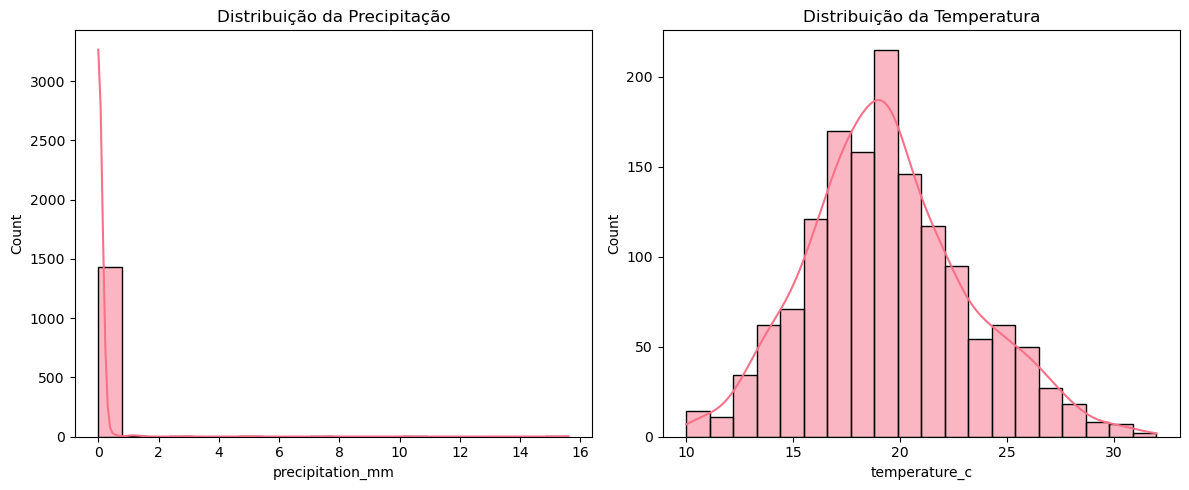

In [6]:
# Distribuição da precipitação e da temperatura
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['precipitation_mm'], bins=20, kde=True)
plt.title('Distribuição da Precipitação')
plt.subplot(1, 2, 2)
sns.histplot(df['temperature_c'], bins=20, kde=True)
plt.title('Distribuição da Temperatura')
plt.tight_layout()
plt.show()

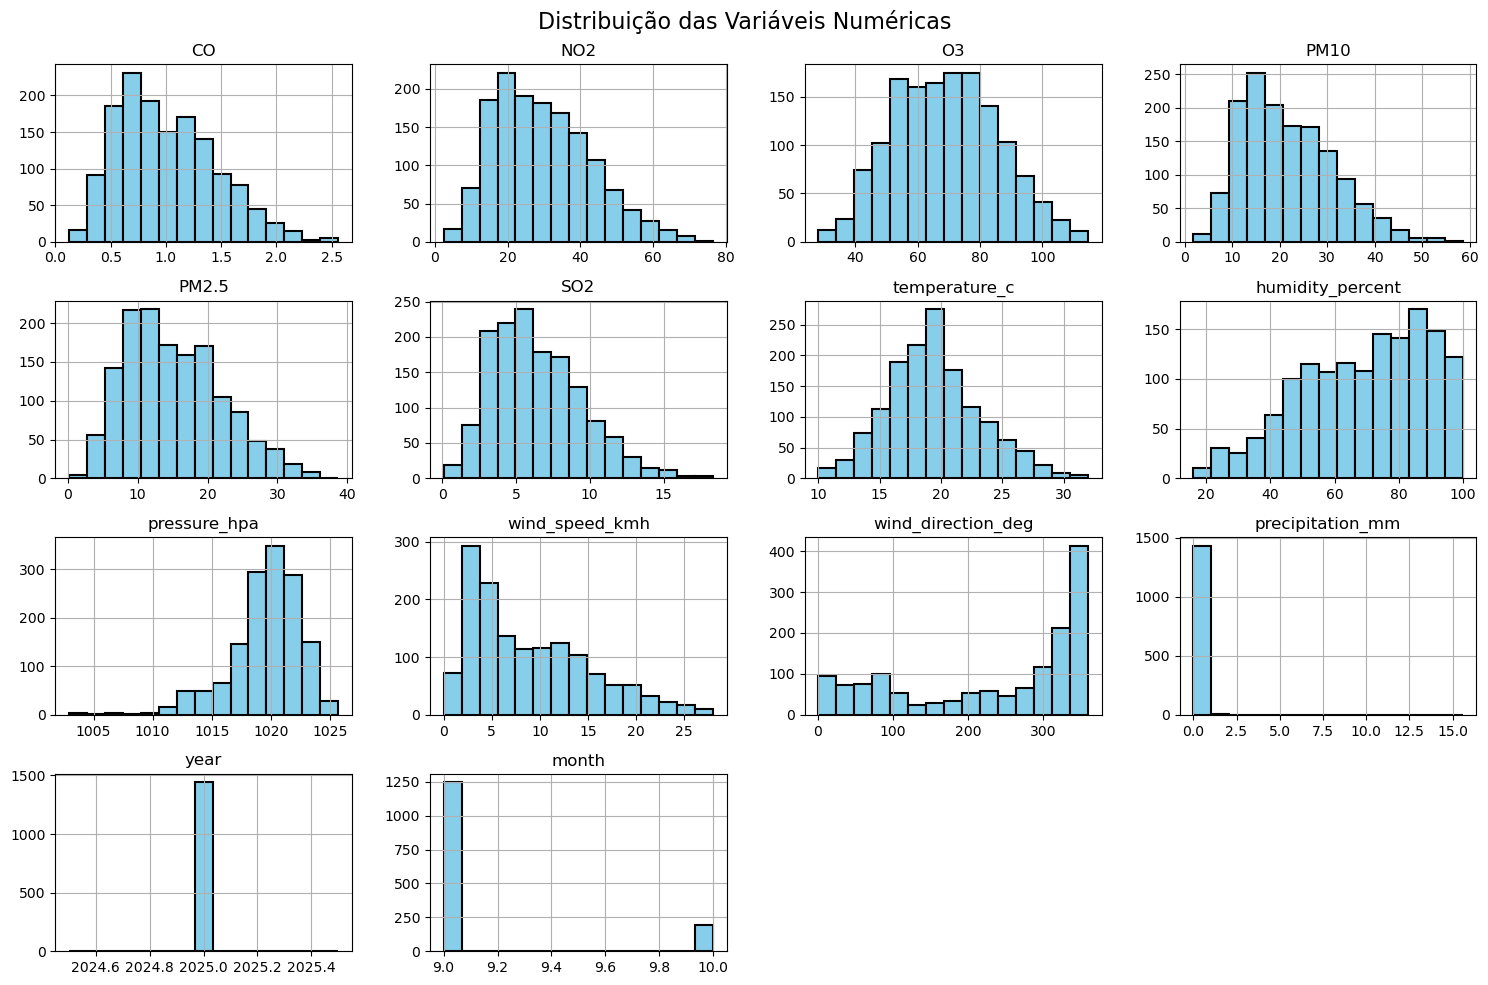

In [7]:
# Histogramas para todas as variáveis numéricas
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols].hist(bins=15, figsize=(15, 10), layout=(4, 4), edgecolor='black', color='skyblue', linewidth=1.5)
plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=16)
plt.tight_layout()
plt.show()

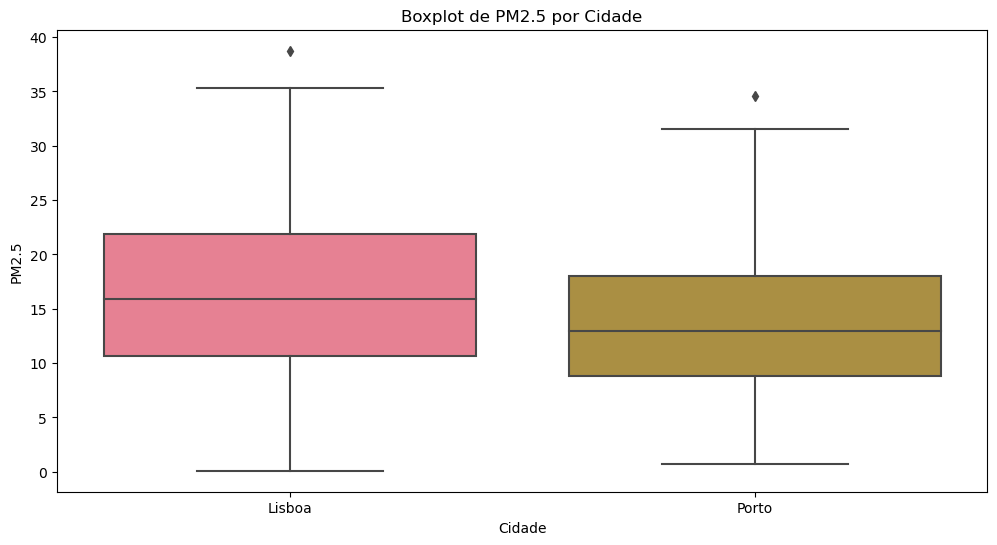

In [8]:
# Boxplot de PM2.5 por cidade
plt.figure(figsize=(12, 6))
sns.boxplot(x='city', y='PM2.5', data=df)
plt.title('Boxplot de PM2.5 por Cidade')
plt.xlabel('Cidade')
plt.ylabel('PM2.5')
plt.show()

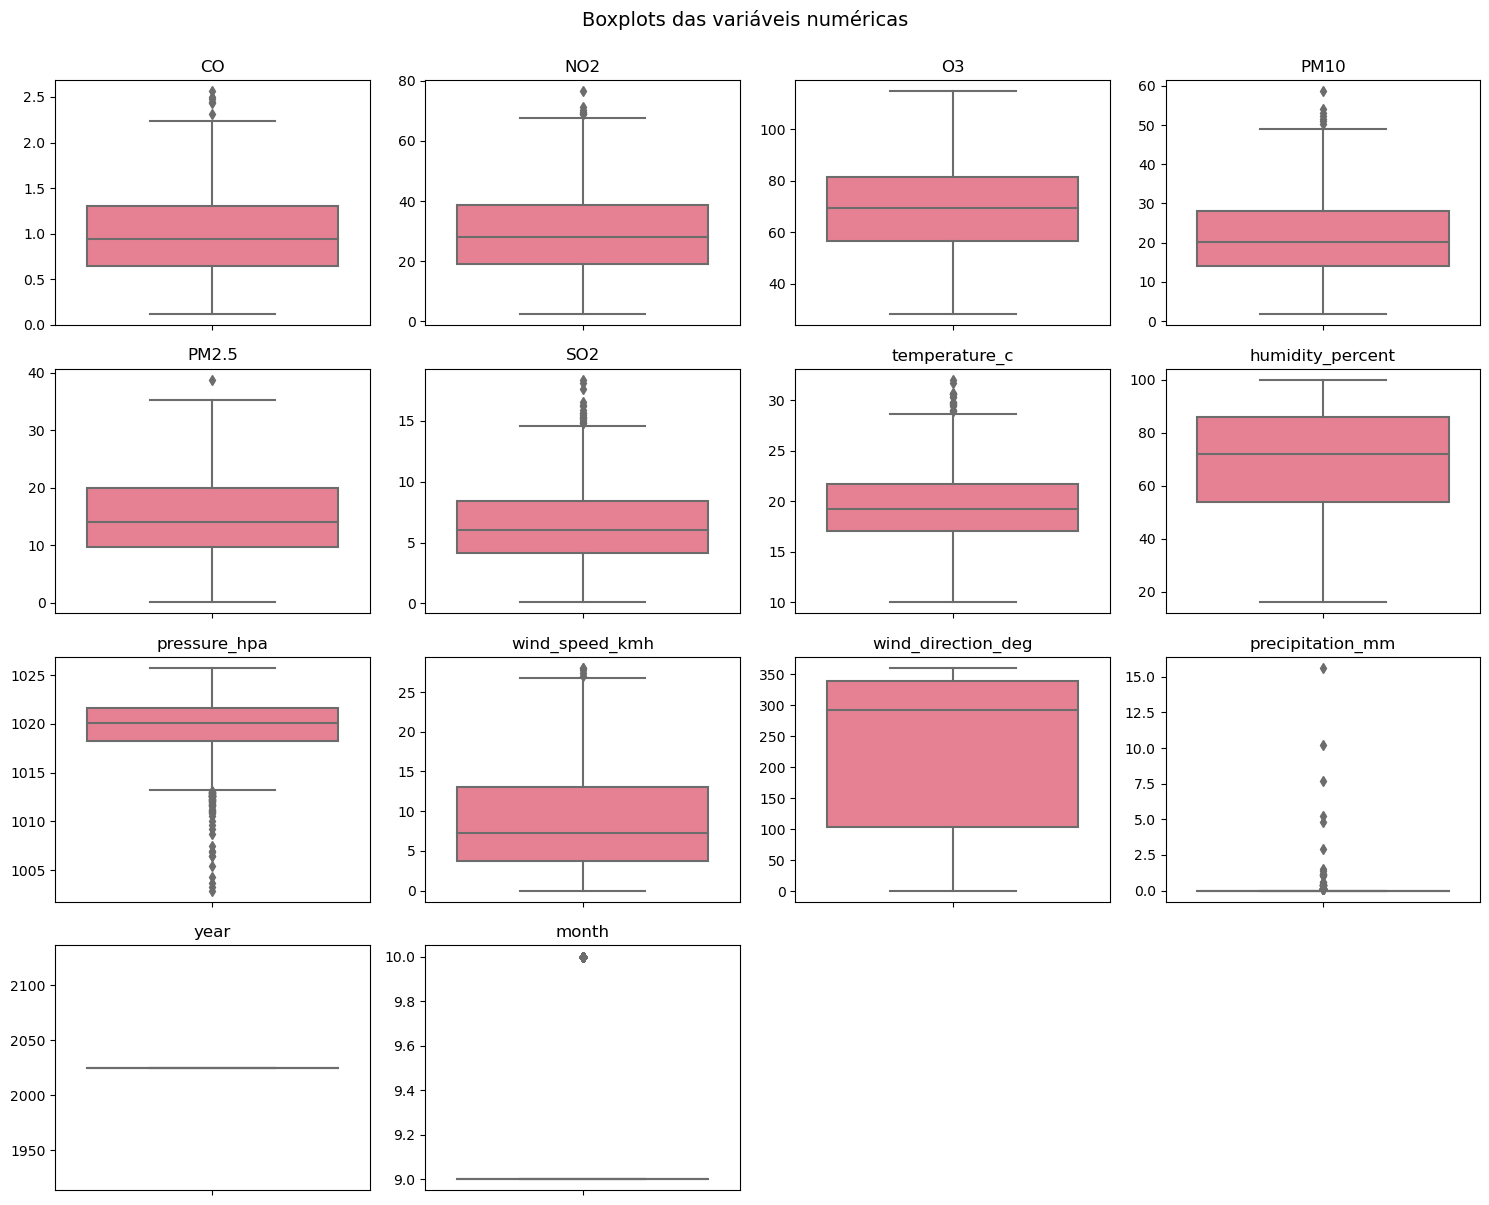

In [9]:
# Boxplots de todas as variáveis numéricas
# (cada uma na sua subplot porque as escalas são muito diferentes)
num_cols = df.select_dtypes(include=[np.number]).columns

ncols = 4
nrows = (len(num_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')

# esconder subplots vazios (caso o nº de variáveis não seja múltiplo de ncols)
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots das variáveis numéricas', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

**Análise dos boxplots:**

Vários outliers visíveis em `PM2.5`, `PM10`, `NO2`, `SO2`, `CO` — mas correspondem a eventos reais de poluição (são exactamente os casos de "má qualidade" que queremos prever). Não removemos.

Os outliers de `pressure_hpa` e `precipitation_mm` são eventos meteorológicos reais (frentes de baixa pressão, chuva pontual) — também mantemos.

O boxplot de `year` é vazio (constante 2025) e o de `month` mostra um "outlier" no 10 que é só desbalanço no nº de linhas (mais Setembro que Outubro). Ambas as colunas serão removidas na fase de tratamento.

## TRATAMENTO DE DADOS (Classificação vs Regressão)

Optámos por usar:

- **Classificação** (target = `air_quality_good`):
    - Logistic Regression — classificador linear
    - Random Forest Classifier — classificador não-linear (ensemble)
    - KNN — classificador baseado em distância (3º para ir além do mínimo de 2)

- **Regressão** (target = `NO2`):
    - Linear Regression — regressor linear
    - Random Forest Regressor — regressor não-linear (ensemble)



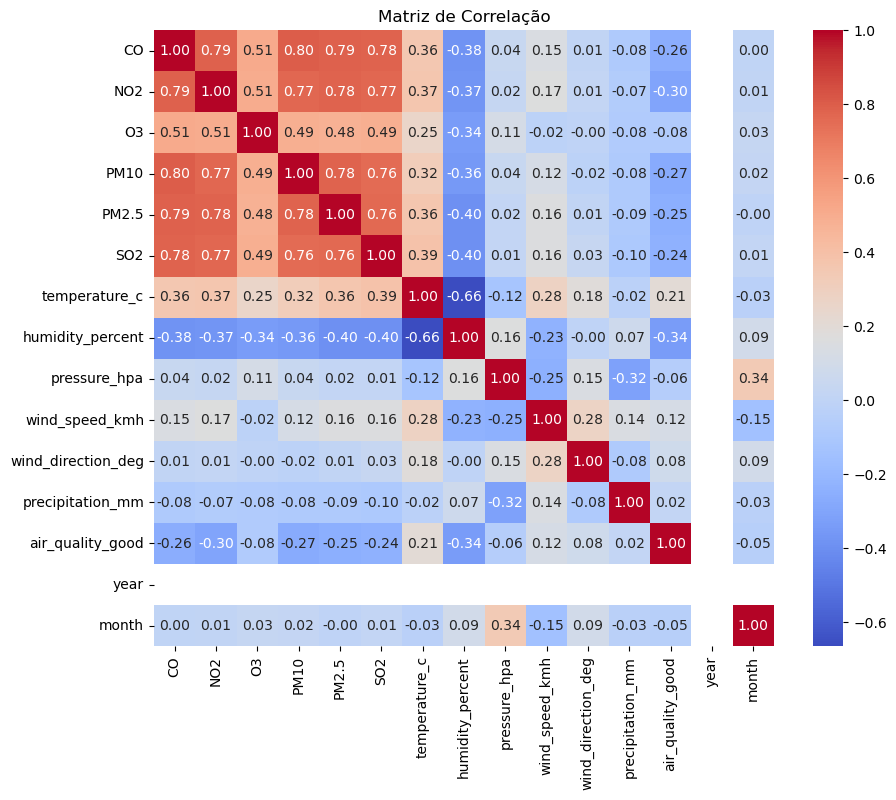

In [10]:
# Matriz de correlação
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=[np.number, 'bool']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

**Análise das correlações com cada target:**

- **`air_quality_good` (target da classificação):** as features `year`, `month`, `precipitation_mm`, `wind_direction_deg`, `pressure_hpa` e `O3` têm muito pouca correlação e provavelmente serão pouco informativas para a previsão.

- **`NO2` (target da regressão):** `pressure_hpa`, `wind_direction_deg`, `precipitation_mm`, `year` e `month` têm baixo grau de correlação e provavelmente não vão ter influência. As features mais importantes serão `CO`, `PM2.5`, `SO2`, `PM10` e `O3`.

- **`CO`:** é a molécula mais correlacionada com as outras moléculas de poluentes (correlações ≥ 0.78 com PM10, PM2.5, SO2 e NO2). Por isso deverá ser redundante e talvez possa ser eliminada para o treino e teste. Vamos testar isso na fase de comparação.

### Pré-processamento comum (aplicado a ambas as tarefas)

Antes de separar em datasets de classificação e regressão, fazemos uma transformação que serve as duas:

**Extrair `hora` e `dia_semana` da coluna `datetime`** — em poluição urbana a hora do dia importa muito (horas de ponta = mais tráfego = mais NO2/PM2.5). Depois apagamos a coluna `datetime` original (string, sem utilidade directa).

In [11]:
# Extrair hora e dia_semana do datetime (formato: 'dd/mm/yy HH:MM')
df['datetime']    = pd.to_datetime(df['datetime'], format='%d/%m/%y %H:%M')
df['hora']        = df['datetime'].dt.hour          # 0-23
df['dia_semana']  = df['datetime'].dt.dayofweek    # 0=segunda, 6=domingo

print(f"hora — valores: {sorted(df['hora'].unique().tolist())}")
print(f"dia_semana — valores: {sorted(df['dia_semana'].unique().tolist())}")
df[['datetime','hora','dia_semana']].head()

hora — valores: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
dia_semana — valores: [0, 1, 2, 3, 4, 5, 6]


,datetime,hora,dia_semana
0,2025-09-05 01:00:00,1,4
1,2025-09-05 02:00:00,2,4
2,2025-09-05 03:00:00,3,4
3,2025-09-05 04:00:00,4,4
4,2025-09-05 05:00:00,5,4


### Tratamento para Classificação

In [12]:
# DataFrame para classificação:
# - target: air_quality_good
# - drop leak (NO2, humidity_percent) — definem a target
# - drop não-úteis (year=constante, month=só 2 valores, city=só 2 valores, datetime=já extraído)
LEAK_CLASSIFICATION = ['NO2', 'humidity_percent']
df_classification = df.drop(columns=LEAK_CLASSIFICATION + ['year', 'month', 'city', 'datetime'])
df_classification.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1442 entries, 0 to 1441
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CO                  1442 non-null   float64
 1   O3                  1442 non-null   float64
 2   PM10                1442 non-null   float64
 3   PM2.5               1442 non-null   float64
 4   SO2                 1442 non-null   float64
 5   temperature_c       1442 non-null   float64
 6   pressure_hpa        1442 non-null   float64
 7   wind_speed_kmh      1442 non-null   float64
 8   wind_direction_deg  1442 non-null   float64
 9   precipitation_mm    1442 non-null   float64
 10  air_quality_good    1442 non-null   bool   
 11  hora                1442 non-null   int64  
 12  dia_semana          1442 non-null   int64  
dtypes: bool(1), float64(10), int64(2)
memory usage: 136.7 KB


In [13]:
# Verificação de nulos e duplicados (só para confirmar novamente que não há)
print(f"Nulos por coluna:\n{df.isnull().sum()}")
print(f"\nNúmero de linhas duplicadas: {df.duplicated().sum()}")

Nulos por coluna:
city                  0
datetime              0
CO                    0
NO2                   0
O3                    0
PM10                  0
PM2.5                 0
SO2                   0
temperature_c         0
humidity_percent      0
pressure_hpa          0
wind_speed_kmh        0
wind_direction_deg    0
precipitation_mm      0
air_quality_good      0
year                  0
month                 0
hora                  0
dia_semana            0
dtype: int64

Número de linhas duplicadas: 0


In [14]:
# Exportar df_classification para CSV (para o train_classification.py)
df_classification.to_csv(CLASSIFICATION_DF, index=False)
print(f"DataFrame para classificação exportado para: {CLASSIFICATION_DF}")

DataFrame para classificação exportado para: /Users/maurasoares/Documents/GitHub/IIA_Project/data/classification_data_clean.csv


### Tratamento para Classificação — variante sem CO (para a comparação)

Olhando para a matriz de correlação acima, o `CO` apresenta correlação **≥ 0.78** com `PM10`, `PM2.5`, `SO2` e `NO2`. Isto sugere que o CO traz informação que já vem nos outros poluentes (todos têm origem nas mesmas fontes — tráfego e indústria).

Para perceber se vale a pena removê-lo, exportamos um **segundo CSV** sem o CO. O `train_classification_comparacao.py` usa este CSV (e o original) para testar 4 combinações: com/sem CO × com/sem SMOTE. Se a melhor combinação não for a baseline, podemos depois actualizar o `train_classification.py` para usar a vencedora.

In [15]:
# Mesmo dataframe de classificacao, mas sem o CO
df_classification_no_co = df_classification.drop(columns=['CO'])
df_classification_no_co.to_csv(CLASSIFICATION_DF_NO_CO, index=False)
print(f'DataFrame sem CO exportado para: {CLASSIFICATION_DF_NO_CO}')
print(f'Shape: {df_classification_no_co.shape}')

DataFrame sem CO exportado para: /Users/maurasoares/Documents/GitHub/IIA_Project/data/classification_data_clean_no_co.csv
Shape: (1442, 12)


### Tratamento para Regressão

In [16]:
# DataFrame para regressão:
# - target: NO2 (numérica)
# - drop leak (air_quality_good) — deriva de NO2
# - drop não-úteis (year, month, city, datetime — mesmas razões da classificação)
LEAK_REGRESSION = ['air_quality_good']
df_regression = df.drop(columns=LEAK_REGRESSION + ['year', 'month', 'city', 'datetime'])
df_regression.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1442 entries, 0 to 1441
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CO                  1442 non-null   float64
 1   NO2                 1442 non-null   float64
 2   O3                  1442 non-null   float64
 3   PM10                1442 non-null   float64
 4   PM2.5               1442 non-null   float64
 5   SO2                 1442 non-null   float64
 6   temperature_c       1442 non-null   float64
 7   humidity_percent    1442 non-null   float64
 8   pressure_hpa        1442 non-null   float64
 9   wind_speed_kmh      1442 non-null   float64
 10  wind_direction_deg  1442 non-null   float64
 11  precipitation_mm    1442 non-null   float64
 12  hora                1442 non-null   int64  
 13  dia_semana          1442 non-null   int64  
dtypes: float64(12), int64(2)
memory usage: 157.8 KB


In [17]:
# Exportar df_regression para CSV (para o train_regression.py)
df_regression.to_csv(REGRESSION_DF, index=False)
print(f"DataFrame para regressão exportado para: {REGRESSION_DF}")

DataFrame para regressão exportado para: /Users/maurasoares/Documents/GitHub/IIA_Project/data/regression_data_clean.csv


### Resumo

A EDA produz **três** ficheiros prontos para os scripts de treino:

| Ficheiro | Linhas | Colunas | Target | Consumido por |
|---|---|---|---|---|
| `data/classification_data_clean.csv`       | 1442 | ~13 | `air_quality_good` | `train_classification.py` (versão final) |
| `data/classification_data_clean_no_co.csv` | 1442 | ~12 | `air_quality_good` | `train_classification_comparacao.py` (comparação) |
| `data/regression_data_clean.csv`           | 1442 | ~14 | `NO2`              | `train_regression.py` |

**Decisões de pré-processamento aplicadas:**

- Filtragem de Lisboa+Porto e remoção de colunas vazias — feito no Módulo 1 (`clean_air_quality.csv`)
- Recálculo da target `air_quality_good` — feito no Módulo 1 (NO2 + humidade)
- Extracção de `hora` e `dia_semana` da coluna `datetime`
- Remoção de `year` (constante), `month` (só 2 valores), `city` (só 2 valores), `datetime` (já extraído)
- Remoção de features que definem a target em cada tarefa (leakage)
- **Extra para a comparação**: exportamos uma segunda versão do dataset de classificação sem o `CO` (informação repetida — correlação ≥ 0.78 com PM10/PM2.5/SO2).

**Iteração experimental:** o `train_classification_comparacao.py` corre os 3 modelos em 4 combinações (com/sem CO × com/sem SMOTE) para perceber se alguma melhora face à baseline do `train_classification.py`. Se uma combinação ganhar, actualizamos a baseline.